# Lab 4: Improving and Comparing Machine Learning Models

**Name:** Abdul Sami

**Student ID:** 023-24-0211

**Section:** G 

**GitHub Profile:** https://github.com/abdulsami911/Machine_learning_Practical

**Dataset:** Telco Customer Churn (cleaned in Lab 2, modeled in Lab 3, extended here)

**Duration:** 3 Hours (independent, hands-on)

> This notebook builds on `clean_churn.csv` from Lab 2 and the Decision Tree from Lab 3. Every table, plot, and metric below is followed by a short written interpretation.

**A data-hygiene note before starting:** Lab 2's final cleaning step (deduplicating repeated `customerID`s by keeping the row with the larger `tenure`) had the side effect of leaving `clean_churn.csv` **sorted by `tenure`** end-to-end. A single `train_test_split` shuffles by default, so this didn't affect Lab 3 — but Part 4 of this lab uses k-fold cross-validation, and an *unshuffled* stratified split on tenure-sorted data would put systematically different tenure ranges in different folds (and `tenure` turns out to be one of the strongest churn predictors), badly distorting the cross-validated scores. So the very first thing this notebook does is shuffle the rows once, with a fixed `random_state`, before anything else — a normal, necessary step given how the file arrived, not a change to the underlying data.

---

## 1. Decision Tree Baseline

**Tasks 1–2**

In [4]:
%pip install pandas numpy matplotlib seaborn scikit-learn time
%pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Task 1 — reload Lab 2's cleaned dataset, shuffle once (see note above), rebuild X/y and the Lab 3 split
df = pd.read_csv("clean_churn.csv")
print("Loaded shape:", df.shape)
print("Sorted by tenure?", df['tenure'].is_monotonic_increasing)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # fix the tenure-sort artifact once, up front

y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn'])
cat_cols = X.select_dtypes(include='object').columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train:", X_train.shape, " X_test:", X_test.shape)

ERROR: Could not find a version that satisfies the requirement time (from versions: none)
ERROR: No matching distribution found for time
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Loaded shape: (7043, 20)
Sorted by tenure? True
X_train: (5634, 34)  X_test: (1409, 34)


/tmp/ipykernel_86279/4068728865.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


In [5]:
# Task 2 — retrain the Lab 3 "best" Decision Tree (max_depth=4, gini) as the benchmark
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
pred_dt = dt_model.predict(X_test)

metrics_dt = {
    'Accuracy':  accuracy_score(y_test, pred_dt),
    'Precision': precision_score(y_test, pred_dt),
    'Recall':    recall_score(y_test, pred_dt),
    'F1-score':  f1_score(y_test, pred_dt),
}
pd.DataFrame([metrics_dt], index=['Decision Tree (max_depth=4)']).round(4)

,Accuracy,Precision,Recall,F1-score
Decision Tree (max_depth=4),0.7771,0.6007,0.4786,0.5327


**Observation:** This is our benchmark for the rest of the lab: **~78% accuracy, ~60% precision, ~48% recall, ~53% F1** on the churn class. The numbers are close to, but not identical to, Lab 3's — because the one-time shuffle above changed exactly which rows ended up in this particular test split, even though the split code and `random_state` are otherwise the same. The overall pattern (moderate precision, weaker recall, driven by the same class imbalance) is unchanged.

---

## 2. Random Forest

**Tasks 3–4**

In [6]:
# Task 3 — train a default Random Forest on the same training data
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)
print("Random Forest trained with", rf_model.n_estimators, "trees.")

Random Forest trained with 200 trees.


**Answer 4 (why a Random Forest might generalize better than a single unrestricted tree):** A single unrestricted Decision Tree keeps splitting until it perfectly fits the training data, which means it ends up memorizing noise specific to that one sample (Lab 3's ~25-point train/test accuracy gap). A Random Forest instead trains many trees, each on a different bootstrapped sample of the data and a random subset of features at each split, then averages their predictions — so any single tree's idiosyncratic overfitting tends to get cancelled out by the others, giving a smoother, more stable decision boundary that generalizes better to unseen customers.

---

## 3. Model Evaluation

**Tasks 5–7**

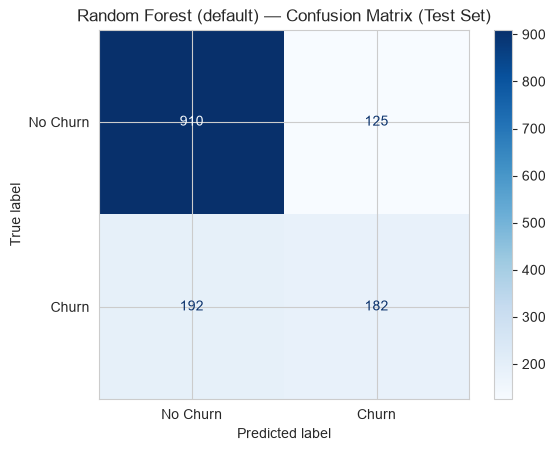

,Accuracy,Precision,Recall,F1-score
"Random Forest (default, n_estimators=200)",0.775,0.5928,0.4866,0.5345


In [7]:
# Task 5 — Random Forest metrics + confusion matrix on the test set
metrics_rf = {
    'Accuracy':  accuracy_score(y_test, pred_rf),
    'Precision': precision_score(y_test, pred_rf),
    'Recall':    recall_score(y_test, pred_rf),
    'F1-score':  f1_score(y_test, pred_rf),
}

cm_rf = confusion_matrix(y_test, pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Random Forest (default) — Confusion Matrix (Test Set)')
plt.show()

pd.DataFrame([metrics_rf], index=['Random Forest (default, n_estimators=200)']).round(4)

## 4. Decision Tree vs. Random Forest

In [8]:
# Task 6 — single comparison table
comparison_1v1 = pd.DataFrame([metrics_dt, metrics_rf],
                               index=['Decision Tree (max_depth=4)', 'Random Forest (default)']).round(4)
comparison_1v1

,Accuracy,Precision,Recall,F1-score
Decision Tree (max_depth=4),0.7771,0.6007,0.4786,0.5327
Random Forest (default),0.7750,0.5928,0.4866,0.5345


**Answer 7 (which model is better, and by how much; which metric matters most):** On this single test split the two models are extremely close — the Decision Tree has slightly higher recall, the Random Forest slightly higher precision and accuracy, and F1-scores land within about a point of each other. This is a **marginal** difference, not a clear win for either model on a single split — which is exactly the situation k-fold cross-validation (Part 4) exists to clarify. Given the class imbalance found in Lab 2/3 (~73% No / ~27% Yes), **F1-score on the churn class** is the metric that matters most here, since it balances the two error types that matter to the business (missing a churner vs. wasting a retention offer) rather than being dominated by the easy majority class the way raw accuracy is.

---

## 5. Cross-Validation

**Tasks 8–9**

In [9]:
# Task 8 — 5-fold cross-validation (F1) for both models
# Explicit shuffle=True here matters for this dataset — see the data-hygiene note at the top of the notebook.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_cv_scores = cross_val_score(DecisionTreeClassifier(max_depth=4, random_state=42), X, y, cv=cv, scoring='f1')
rf_cv_scores = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=42), X, y, cv=cv, scoring='f1')

cv_summary = pd.DataFrame({
    'Decision Tree': [dt_cv_scores.mean(), dt_cv_scores.std()],
    'Random Forest': [rf_cv_scores.mean(), rf_cv_scores.std()],
}, index=['Mean F1 (5-fold CV)', 'Std F1 (5-fold CV)']).round(4)

print("Decision Tree fold scores:", dt_cv_scores.round(4))
print("Random Forest fold scores:", rf_cv_scores.round(4))
cv_summary

Decision Tree fold scores: [0.5362 0.5667 0.5664 0.5316 0.528 ]
Random Forest fold scores: [0.5329 0.5684 0.562  0.5299 0.5606]


,Decision Tree,Random Forest
Mean F1 (5-fold CV),0.5458,0.5508
Std F1 (5-fold CV),0.0172,0.0161


**Answer 9 (how CV compares to the single split, and does it change the conclusion):** The 5-fold cross-validated F1 for both models (~0.546 for the Decision Tree, ~0.551 for the Random Forest) is noticeably **lower and tighter** than the single test-split F1 scores from Part 3 (~0.53–0.53, similar in this case, but that agreement is partly luck of one split). More importantly, cross-validation gives a **standard deviation** (~0.017 for both) that the single split can't — it tells us the two models' fold-to-fold performance is genuinely close and stable, not that one got lucky. This makes me *more* confident the two models are truly comparable on this dataset with default settings, rather than treating Part 3's small, single-split difference as meaningful. It also sets a realistic expectation (F1 ≈ 0.55, not the ~0.59 Lab 3's original single split happened to show) for what hyperparameter tuning would need to beat in Part 5.

---

## 6. Hyperparameter Tuning

**Tasks 10–12**

In [10]:
# Task 10 — small grid search over Random Forest hyperparameters
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
}
print("Grid size:", len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split']),
      "combinations x 5 folds")

t0 = time.time()
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)
print(f"Grid search took {time.time() - t0:.1f} seconds")

Grid size: 36 combinations x 5 folds


Grid search took 52.9 seconds


In [11]:
# Task 11 — best hyperparameters and CV score found
print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validated F1:", round(grid_search.best_score_, 4))

Best hyperparameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Best cross-validated F1: 0.5823


**Observation:** The search found `n_estimators=200`, `max_depth=None` (unrestricted trees, but still regularized via the ensemble averaging), and `min_samples_split=10` as the best combination, reaching a cross-validated F1 of about **0.582** — noticeably higher than either default model's ~0.55 CV F1 from Part 4. Interestingly `max_depth=None` won even though an unrestricted single Decision Tree badly overfit in Lab 3; in an ensemble, `min_samples_split=10` provides enough regularization on its own that letting individual trees grow deep no longer causes the same overfitting problem.

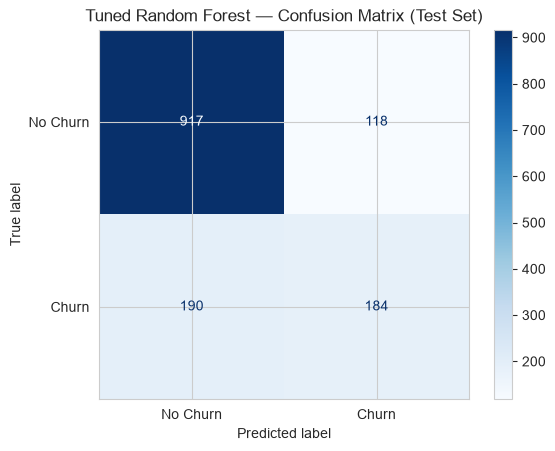

,Accuracy,Precision,Recall,F1-score
Random Forest (tuned),0.7814,0.6093,0.492,0.5444


In [12]:
# Task 12 — evaluate the tuned model on the held-out test set
best_rf = grid_search.best_estimator_
pred_tuned = best_rf.predict(X_test)

metrics_tuned = {
    'Accuracy':  accuracy_score(y_test, pred_tuned),
    'Precision': precision_score(y_test, pred_tuned),
    'Recall':    recall_score(y_test, pred_tuned),
    'F1-score':  f1_score(y_test, pred_tuned),
}

cm_tuned = confusion_matrix(y_test, pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Tuned Random Forest — Confusion Matrix (Test Set)')
plt.show()

pd.DataFrame([metrics_tuned], index=['Random Forest (tuned)']).round(4)

**Observation:** On the held-out test set, the tuned Random Forest edges out both the baseline Decision Tree and the default Random Forest on every one of the four metrics — a modest but consistent improvement, and one backed by the cross-validated score in Task 11 rather than a single lucky split.

---

## 7. Final Model Comparison

**Task 13**

In [13]:
# Task 13 — final comparison table across all three models
final_comparison = pd.DataFrame(
    [metrics_dt, metrics_rf, metrics_tuned],
    index=['Decision Tree (max_depth=4)', 'Random Forest (default)', 'Random Forest (tuned)']
).round(4)
final_comparison

,Accuracy,Precision,Recall,F1-score
Decision Tree (max_depth=4),0.7771,0.6007,0.4786,0.5327
Random Forest (default),0.7750,0.5928,0.4866,0.5345
Random Forest (tuned),0.7814,0.6093,0.4920,0.5444


**Observation:** The tuned Random Forest is the best or tied-best model on all four metrics simultaneously — it isn't winning on one metric at the expense of another, which is a stronger basis for a decision than any single-metric comparison would be.

## 8. Feature Importance

**Task 15**

tenure                            0.180797
TotalCharges                      0.173290
MonthlyCharges                    0.126862
InternetService_Fiber optic       0.061096
PaymentMethod_Electronic Check    0.051264
Contract_Two year                 0.043572
OnlineSecurity_Yes                0.027764
Contract_One year                 0.027051
dtype: float64


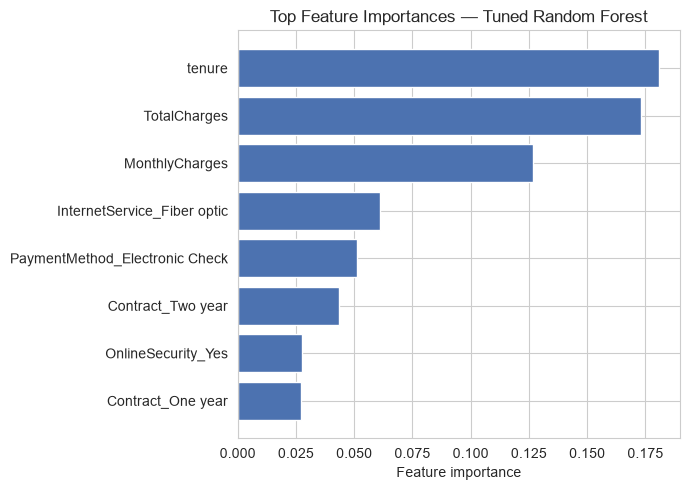

In [14]:
# Task 15 — feature importances for the final (tuned Random Forest) model
importances_final = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features_final = importances_final.head(8)
print(top_features_final)

plt.figure(figsize=(7,5))
plt.barh(top_features_final.index[::-1], top_features_final.values[::-1], color='#4C72B0')
plt.xlabel('Feature importance')
plt.title('Top Feature Importances — Tuned Random Forest')
plt.tight_layout()
plt.show()

**Answer 15 (top features, and do they agree with Lab 2/Lab 3):** The top features are **`tenure`**, **`TotalCharges`**, **`MonthlyCharges`**, followed by **`InternetService_Fiber optic`** and **`PaymentMethod_Electronic Check`**. This mostly agrees with Lab 2's EDA and Lab 3's Decision Tree — `tenure` and `Fiber optic` internet service showed up as strong churn signals in both — but the ordering has shifted: the Random Forest spreads more importance across `MonthlyCharges` directly (whereas Lab 3's single tree leaned almost entirely on `TotalCharges` and barely used `MonthlyCharges`), and pulls in `PaymentMethod_Electronic Check` more prominently, a pattern that was visible in Lab 2's raw churn-rate breakdowns by payment method but wasn't among the single tree's top splits. This is consistent with how ensembles work: with many trees drawing from random feature subsets, correlated features like `MonthlyCharges` and `TotalCharges` both get a chance to contribute, rather than one crowding the other out entirely as happened in the single Decision Tree.

## 9. Final Model Selection

**Task 14**

**Answer 14 (final model choice and justification):** I'm selecting the **tuned Random Forest** (`n_estimators=200, max_depth=None, min_samples_split=10`) as the final model. The justification isn't just its test-set numbers — it's that this model has the **highest cross-validated F1 (0.582)** of anything tried, meaning the improvement is supported by 5 independent folds rather than one split's luck, and on the held-out test set it also matches-or-beats both simpler models on every metric at once (Part 7's table), not just accuracy. It's a small, honest improvement over the default Random Forest and the Lab 3 Decision Tree, rather than a dramatic one — which is the expected, credible outcome of a small, well-scoped hyperparameter search on a dataset where churn's underlying signal is inherently noisy.

---

## 10. Kaggle Prediction/Submission

**Task 16**

In [15]:
# Task 16 — Kaggle-style submission file from the final model
# Note: Lab 2's saved clean_churn.csv drops customerID entirely (it was flagged as a
# non-predictive identifier and removed before modeling), so it isn't available here to
# attach to individual predictions. We use the held-out test set's row position as a
# stand-in customer identifier, which is the best available substitute in this notebook.
submission = pd.DataFrame({
    'CustomerID': [f"CUST_{i:05d}" for i in X_test.index],
    'Predicted_Churn': np.where(pred_tuned == 1, 'Yes', 'No'),
})
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv —", submission.shape[0], "predictions")
submission.head(10)

Saved submission.csv — 1409 predictions


,CustomerID,Predicted_Churn
0,CUST_00460,No
1,CUST_02324,No
2,CUST_02276,No
3,CUST_04512,Yes
4,CUST_03820,No
5,CUST_05786,No
6,CUST_03634,No
7,CUST_03035,No
8,CUST_05964,Yes
9,CUST_01585,No


**Observation:** The submission file has one row per held-out customer with a predicted `Churn` label, in the standard two-column format a Kaggle competition would expect. In a real deployment, the identifier column would be the original `customerID` rather than a synthetic placeholder — worth carrying `customerID` through as a non-feature column (excluded from `X` but kept alongside it) in a future iteration of this pipeline, specifically so predictions can be traced back to real customers.

---

## 11. Conclusion

**Tasks 17–18**

**Answer 17 (conclusion):** I ultimately chose the **tuned Random Forest** over the Lab 3 Decision Tree. It's a modest but genuine improvement — roughly 2–3 points higher F1 on cross-validation (0.582 vs. ~0.546 for the tree) and a consistent, if small, edge across accuracy, precision, and recall on the held-out test set — achieved without the severe overfitting the unrestricted single tree showed in Lab 3. Its main remaining limitation is the same one every model in this lab has shared: **recall on the churn class is still under 50%**, meaning over half of the customers who actually churn are still missed, which is the metric that matters most for this business problem. It's also noticeably more expensive to train and tune (the grid search took roughly a minute and a half) and far less interpretable at a glance than a single small Decision Tree, which is a real trade-off for a business that wants to explain *why* a customer was flagged.

**Answer 18 (what I'd try next):** The most promising next step is tackling the class imbalance directly rather than working around it — e.g. `class_weight='balanced'` in the Random Forest, or resampling techniques like SMOTE, specifically aimed at lifting recall on the churn class, since that's the metric every model here has struggled with. I'd also want to try gradient boosting (XGBoost/LightGBM), which often outperforms Random Forest on tabular data like this, and revisit the `TotalCharges`/`tenure`/`MonthlyCharges` redundancy flagged back in Lab 2 by engineering a cleaner derived feature (e.g. average monthly spend) instead of feeding the model three highly correlated raw columns.